<a href="https://colab.research.google.com/github/rishike/llm_from_scratch/blob/main/GELU_Activation_Function_in_the_LLM_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn

In [2]:
class Gelu(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
    ))

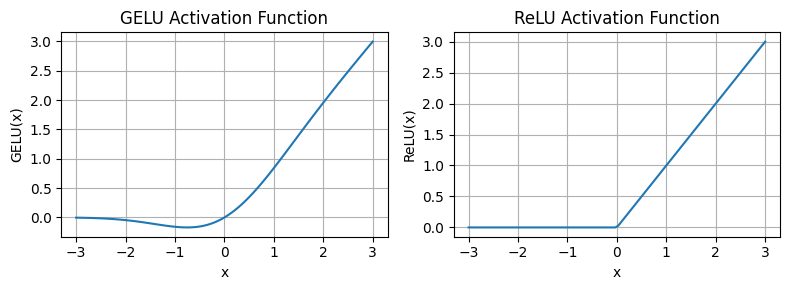

In [3]:
import matplotlib.pyplot as plt

gelu, relu = Gelu(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
  plt.subplot(1,2, i)
  plt.plot(x, y)
  plt.title(f"{label} Activation Function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)

plt.tight_layout()
plt.show()

ReLu is a piecewise linear function that ouputs the inputs directly if it is positive; otherwise, if outputs zero.
Gelu is smooth, nonlinear function that approximates relu but with a non-zero gradient for negative values.

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties during training , as it allows for more nuanced adjustments to the model's parameters.

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures.

Moreover, unlike RELU, which ouputs zero for any negative input, GELU allows for a small, non zero output for negative values.

This characterstic means that during the training process neurons that recieve negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs

In [4]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        Gelu(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
    )

  def forward(self, x):
    return self.layers(x)


In [5]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [7]:
ffn = FeedForward(GPT_CONFIG_124M).forward(torch.rand(2,3,768))
ffn

tensor([[[-0.0834,  0.0258, -0.1784,  ...,  0.0571, -0.1722, -0.0381],
         [-0.0761,  0.0088, -0.1339,  ...,  0.0407, -0.1420, -0.0196],
         [-0.0438,  0.0715, -0.0173,  ..., -0.0099, -0.0916, -0.0614]],

        [[-0.0310, -0.0918, -0.0579,  ..., -0.0312, -0.1192, -0.0511],
         [-0.0066,  0.1202, -0.0613,  ..., -0.0833, -0.1727,  0.0446],
         [-0.1404,  0.0467, -0.2315,  ...,  0.0473, -0.1291, -0.0434]]],
       grad_fn=<ViewBackward0>)

The feed forward implemented in this section plays a crucial role in enhancing the model's ablility to learn from and generalize the data.
Although the input and output dimensions of this module are the same, it internally expands the embedding dimensions into a higher-dimensional space through the first linear space.
This expansion is followed by a non-linear GELU activation, and then a contraction back to the orignal dimension with second linear transformation